# 01 - Análisis exploratorio de los datos por calle de Algeciras
En este Notebook se realiza el análisis exploratorio de datos del archivo data/raw/algeciras/260522_Tabla_resultados_Viario_Algeciras.xlsx.

Los objetivos principales son:
* Importar los datos, y comprobar cómo está estructurado el dataset.
* Limpiar los datos para eliminar valores nulos o erróneos que puedan afectar al análisis.
* Tratar de identificar a qué carácterísticas de accesibilidad pertenece cada variable.
* Tratar de localizar las variables candidatas a ser clases o etiquetas, y que indican el grado o puntuación de accesibilidad, u otro tipo de resultado.
* Realizar un análisis estadístico de las variables.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from urban_accessibility_ml.config import (
    INTERIM_DATA_DIR,
    RAW_DATA_DIR,
)
ALGECIRAS_DIR = RAW_DATA_DIR / "algeciras"
INTERIM_ALGECIRAS_DIR = INTERIM_DATA_DIR / "algeciras"

2026-10-07 20:00:32.215 | INFO     | urban_accessibility_ml.config:<module>:11 - PROJ_ROOT path is: /home/victor-pariente/dev/tfm/tfm-urban-accessibility-ml


## Carga de datos y exploración inicial

En primer lugar, cargamos los datos del xlsx en un dataframe.

In [2]:
# Load Algeciras streets data
df_alg_streets = pd.read_excel(ALGECIRAS_DIR / "260522_Tabla_resultados_Viario_Algeciras.xlsx")

Realizamos una rápida exploración de las primeras filas y últimas, las dimensiones, y las columnas.

In [3]:
# Display the first and last 10 rows of the street dataset
display(df_alg_streets.head(10))
display(df_alg_streets.tail(10))

,REFERENCIA,NOMBRE,Barriada,TIPOLOGÍA,PROPUESTA,PUNT_PEND_FU,PUNT_PEND_SE,PUNT_PEND_CG,PUNT_PEND_GB,PUNT_ANCH_FU,...,PIC_CRUC_CG,PIC_SEÑA_FU,PIC_SEÑA_SE,PIC_SEÑA_CG,PIC_ILUM_FU,PIC_ILUM_SE,PIC_ILUM_CG,PIC_MOBI_FU,PIC_MOBI_SE,PIC_MOBI_CG
0,0001,Calle Juan Pérez Arriete,El Rosario,Tráfico diferenciado 2 o más carriles,Mejora en Vía existente: Tráfico diferenciado ...,5,4,4,4.333333,5,...,A,B,B,C,B,A,A,B,B,B
1,0002,Avenida Virgen del Carmen,La Reconquista,Tráfico diferenciado 2 o más carriles,Mejora en Vía existente: Tráfico diferenciado ...,5,4,4,4.333333,5,...,A,B,B,C,B,A,A,B,B,B
2,0003A,Paseo De la Conferencia 1,Puerto,Tráfico diferenciado 2 o más carriles,Mejora en Vía existente: Tráfico diferenciado ...,5,4,4,4.333333,5,...,A,B,B,C,B,A,A,B,B,B
3,0003B,Paseo De la Conferencia,La Banda del Río,Tráfico diferenciado 2 o más carriles,Mejora en Vía existente: Tráfico diferenciado ...,0,1,2,1,0,...,C,C,C,C,B,B,B,C,C,C
4,0004,Calle Carteya,La Caridad,Tráfico diferenciado 2 o más carriles,Mejora en Vía existente: Tráfico diferenciado ...,5,4,4,4.333333,0,...,B,B,B,C,B,B,B,C,C,C
5,0004B,Calle Carteya B,La Banda del Río,Tráfico diferenciado 2 o más carriles,Mejora en Vía existente: Tráfico diferenciado ...,5,4,4,4.333333,0,...,C,C,C,C,B,B,B,C,C,C
6,0005A,Avenida Gesto por la Paz,La Caridad,Tráfico diferenciado 2 o más carriles,Mejora en Vía existente: Tráfico diferenciado ...,5,4,4,4.333333,3,...,B,C,C,C,B,B,B,C,C,C
7,0005B,Avenida Gesto por la Paz,El Saladillo,Tráfico diferenciado 2 o más carriles,Mejora en Vía existente: Tráfico diferenciado ...,5,4,4,4.333333,3,...,B,B,B,C,B,B,B,B,B,B
8,0006,Calle Patriarca Doctor Don Ramón Pérez Rodríguez,Renfe,Tráfico diferenciado 2 o más carriles,Mejora en Vía existente: Tráfico diferenciado ...,2,2,3,2.333333,3,...,B,C,C,C,B,B,B,C,C,C
9,0007,Calle Ruíz Zorrilla,Centro,Tráfico diferenciado 2 o más carriles,Mejora en Vía existente: Tráfico diferenciado ...,5,4,4,4.333333,5,...,B,B,B,C,B,B,B,C,C,C


,REFERENCIA,NOMBRE,Barriada,TIPOLOGÍA,PROPUESTA,PUNT_PEND_FU,PUNT_PEND_SE,PUNT_PEND_CG,PUNT_PEND_GB,PUNT_ANCH_FU,...,PIC_CRUC_CG,PIC_SEÑA_FU,PIC_SEÑA_SE,PIC_SEÑA_CG,PIC_ILUM_FU,PIC_ILUM_SE,PIC_ILUM_CG,PIC_MOBI_FU,PIC_MOBI_SE,PIC_MOBI_CG
600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
601,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
603,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
604,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
605,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
608,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Display the number of rows and columns of the street dataset
print('Dimensions: ' + str(df_alg_streets.shape))

# Exploration of the column names and types
print("Info:")
display(df_alg_streets.info())

# Describe the data
print("Description:")
display(df_alg_streets.describe())

Dimensions: (610, 73)
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610 entries, 0 to 609
Data columns (total 73 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   REFERENCIA     506 non-null    object 
 1   NOMBRE         506 non-null    object 
 2   Barriada       506 non-null    object 
 3   TIPOLOGÍA      506 non-null    object 
 4   PROPUESTA      508 non-null    object 
 5   PUNT_PEND_FU   508 non-null    object 
 6   PUNT_PEND_SE   508 non-null    object 
 7   PUNT_PEND_CG   508 non-null    object 
 8   PUNT_PEND_GB   508 non-null    object 
 9   PUNT_ANCH_FU   508 non-null    object 
 10  PUNT_ANCH_SE   508 non-null    object 
 11  PUNT_ANCH_CG   508 non-null    object 
 12  PUNT_ANCH_GB   508 non-null    object 
 13  PUNT_PAVI_FU   508 non-null    object 
 14  PUNT_PAVI_SE   508 non-null    object 
 15  PUNT_PAVI_CG   508 non-null    object 
 16  PUNT_PAVI_GB   508 non-null    object 
 17  PUNT_CRUC_FU   508 non-nul

None

Description:


,Unnamed: 51
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


Tras una primera exploración de los datos, se puede observar:
* El conjunto de datos tiene un total de 610 filas y 73 columnas.
* Al menos las 10 últimas filas no tienen ningún tipo de información.
* La mayoría de filas tienen el tipo de dato object, por lo que al ejecutar describe() no obtenemos información útil.
* La columna 51 no tiene nombre, tiene todos los valores nulos, y es la única con tipo de datos float64.

En cuanto a las primeras columnas:
* La columna REFERENCIA es de tipo secuencia de caracteres, y actúa como índice de la tabla, y tiene el formato CCCC(L), donde C es una cifra y L (opcional) es una letra.
    * Cuando la REFERENCIA tiene letra, parece debido a que hay una misma calle en dos barriadas.
* La columna NOMBRE, de tipo secuencia de caracteres, contiene el nombre de la calle, con el tipo de calle y el nombre.
    * En algunos casos, cuando la calle es compartida entre barriadas, el nombre de la calle tiene un añadido, como un número o una letra. Por ejemplo, "Paseo De la Conferencia 1".
* La columna TIPOLOGÍA contiene el tipo de calle que es, en cuanto al tipo de tráfico que puede pasar.
* La columna PROPUESTA contiene la propuesta de actuación en la calle.

Por otro lado, se puede comprobar que hay valores como PUNT. MEDIA o PIC. MEDIA, que parecen agregadores totales. Por lo que vamos a analizar si hay filas que no contienen información de las calles, o que están vacías.

In [5]:
# Nulls per column
display(df_alg_streets.isna().sum())

REFERENCIA     104
NOMBRE         104
Barriada       104
TIPOLOGÍA      104
PROPUESTA      102
              ... 
PIC_ILUM_SE    104
PIC_ILUM_CG    104
PIC_MOBI_FU    104
PIC_MOBI_SE    104
PIC_MOBI_CG    104
Length: 73, dtype: int64

## Limpieza de datos

Parece que hay bastantes filas sin referencia, nombre, barriada o propuesta (104). Vamos a comprobar qué información se muestra en esas 104 filas.

In [6]:
df_alg_streets_no_reference = df_alg_streets[df_alg_streets['REFERENCIA'].isna()]
display(df_alg_streets_no_reference.info())
display(df_alg_streets_no_reference.head(10))
display(df_alg_streets_no_reference.tail(10))

<class 'pandas.core.frame.DataFrame'>
Index: 104 entries, 506 to 609
Data columns (total 73 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   REFERENCIA     0 non-null      object 
 1   NOMBRE         0 non-null      object 
 2   Barriada       0 non-null      object 
 3   TIPOLOGÍA      0 non-null      object 
 4   PROPUESTA      2 non-null      object 
 5   PUNT_PEND_FU   2 non-null      object 
 6   PUNT_PEND_SE   2 non-null      object 
 7   PUNT_PEND_CG   2 non-null      object 
 8   PUNT_PEND_GB   2 non-null      object 
 9   PUNT_ANCH_FU   2 non-null      object 
 10  PUNT_ANCH_SE   2 non-null      object 
 11  PUNT_ANCH_CG   2 non-null      object 
 12  PUNT_ANCH_GB   2 non-null      object 
 13  PUNT_PAVI_FU   2 non-null      object 
 14  PUNT_PAVI_SE   2 non-null      object 
 15  PUNT_PAVI_CG   2 non-null      object 
 16  PUNT_PAVI_GB   2 non-null      object 
 17  PUNT_CRUC_FU   2 non-null      object 
 18  PUNT_CRUC_SE 

None

,REFERENCIA,NOMBRE,Barriada,TIPOLOGÍA,PROPUESTA,PUNT_PEND_FU,PUNT_PEND_SE,PUNT_PEND_CG,PUNT_PEND_GB,PUNT_ANCH_FU,...,PIC_CRUC_CG,PIC_SEÑA_FU,PIC_SEÑA_SE,PIC_SEÑA_CG,PIC_ILUM_FU,PIC_ILUM_SE,PIC_ILUM_CG,PIC_MOBI_FU,PIC_MOBI_SE,PIC_MOBI_CG
506,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
507,NaN,NaN,NaN,NaN,PUNT. MEDIA,2.913043,2.675889,3.237154,2.942029,2.201581,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
508,NaN,NaN,NaN,NaN,PIC. MEDIA,B,B,B,B,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
510,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
512,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,REFERENCIA,NOMBRE,Barriada,TIPOLOGÍA,PROPUESTA,PUNT_PEND_FU,PUNT_PEND_SE,PUNT_PEND_CG,PUNT_PEND_GB,PUNT_ANCH_FU,...,PIC_CRUC_CG,PIC_SEÑA_FU,PIC_SEÑA_SE,PIC_SEÑA_CG,PIC_ILUM_FU,PIC_ILUM_SE,PIC_ILUM_CG,PIC_MOBI_FU,PIC_MOBI_SE,PIC_MOBI_CG
600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
601,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
603,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
604,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
605,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
608,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Vemos que la mayoría de filas están vacías, exceptuando 2 para las columnas PUNT_* (como PUNT_PEND_FU), 48 para PUNT_MOBI_SE, 97 para la columna sin nombre (índice 37), y 99 para presupuesto, 88 para fase, o 91 para PIC_TOTAL.

Vamos a analizar estos casos.

In [7]:
# Analyze rows with not null values for specific columns
display(df_alg_streets_no_reference[~df_alg_streets['PUNT_PEND_FU'].isna()])
display(df_alg_streets_no_reference[~df_alg_streets['PUNT_MOBI_SE'].isna()])
display(df_alg_streets_no_reference[~df_alg_streets.iloc[:, 37].isna()])
display(df_alg_streets_no_reference[~df_alg_streets['PRESUPUESTO'].isna()])
display(df_alg_streets_no_reference[~df_alg_streets['FASE'].isna()])
display(df_alg_streets_no_reference[~df_alg_streets['PIC_TOTAL'].isna()])

/tmp/ipykernel_70378/1727977827.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  display(df_alg_streets_no_reference[~df_alg_streets['PUNT_PEND_FU'].isna()])


,REFERENCIA,NOMBRE,Barriada,TIPOLOGÍA,PROPUESTA,PUNT_PEND_FU,PUNT_PEND_SE,PUNT_PEND_CG,PUNT_PEND_GB,PUNT_ANCH_FU,...,PIC_CRUC_CG,PIC_SEÑA_FU,PIC_SEÑA_SE,PIC_SEÑA_CG,PIC_ILUM_FU,PIC_ILUM_SE,PIC_ILUM_CG,PIC_MOBI_FU,PIC_MOBI_SE,PIC_MOBI_CG
507,NaN,NaN,NaN,NaN,PUNT. MEDIA,2.913043,2.675889,3.237154,2.942029,2.201581,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
508,NaN,NaN,NaN,NaN,PIC. MEDIA,B,B,B,B,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


/tmp/ipykernel_70378/1727977827.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  display(df_alg_streets_no_reference[~df_alg_streets['PUNT_MOBI_SE'].isna()])


,REFERENCIA,NOMBRE,Barriada,TIPOLOGÍA,PROPUESTA,PUNT_PEND_FU,PUNT_PEND_SE,PUNT_PEND_CG,PUNT_PEND_GB,PUNT_ANCH_FU,...,PIC_CRUC_CG,PIC_SEÑA_FU,PIC_SEÑA_SE,PIC_SEÑA_CG,PIC_ILUM_FU,PIC_ILUM_SE,PIC_ILUM_CG,PIC_MOBI_FU,PIC_MOBI_SE,PIC_MOBI_CG
507,NaN,NaN,NaN,NaN,PUNT. MEDIA,2.913043,2.675889,3.237154,2.942029,2.201581,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
508,NaN,NaN,NaN,NaN,PIC. MEDIA,B,B,B,B,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
522,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
523,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
525,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


/tmp/ipykernel_70378/1727977827.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  display(df_alg_streets_no_reference[~df_alg_streets.iloc[:, 37].isna()])


...

,REFERENCIA,NOMBRE,Barriada,TIPOLOGÍA,PROPUESTA,PUNT_PEND_FU,PUNT_PEND_SE,PUNT_PEND_CG,PUNT_PEND_GB,PUNT_ANCH_FU,...,PIC_CRUC_CG,PIC_SEÑA_FU,PIC_SEÑA_SE,PIC_SEÑA_CG,PIC_ILUM_FU,PIC_ILUM_SE,PIC_ILUM_CG,PIC_MOBI_FU,PIC_MOBI_SE,PIC_MOBI_CG
507,NaN,NaN,NaN,NaN,PUNT. MEDIA,2.913043,2.675889,3.237154,2.942029,2.201581,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
508,NaN,NaN,NaN,NaN,PIC. MEDIA,B,B,B,B,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
510,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
512,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
605,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
608,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


/tmp/ipykernel_70378/1727977827.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  display(df_alg_streets_no_reference[~df_alg_streets['FASE'].isna()])


,REFERENCIA,NOMBRE,Barriada,TIPOLOGÍA,PROPUESTA,PUNT_PEND_FU,PUNT_PEND_SE,PUNT_PEND_CG,PUNT_PEND_GB,PUNT_ANCH_FU,...,PIC_CRUC_CG,PIC_SEÑA_FU,PIC_SEÑA_SE,PIC_SEÑA_CG,PIC_ILUM_FU,PIC_ILUM_SE,PIC_ILUM_CG,PIC_MOBI_FU,PIC_MOBI_SE,PIC_MOBI_CG
522,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
523,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
525,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
605,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
608,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


/tmp/ipykernel_70378/1727977827.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  display(df_alg_streets_no_reference[~df_alg_streets['PIC_TOTAL'].isna()])


,REFERENCIA,NOMBRE,Barriada,TIPOLOGÍA,PROPUESTA,PUNT_PEND_FU,PUNT_PEND_SE,PUNT_PEND_CG,PUNT_PEND_GB,PUNT_ANCH_FU,...,PIC_CRUC_CG,PIC_SEÑA_FU,PIC_SEÑA_SE,PIC_SEÑA_CG,PIC_ILUM_FU,PIC_ILUM_SE,PIC_ILUM_CG,PIC_MOBI_FU,PIC_MOBI_SE,PIC_MOBI_CG
517,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
518,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
519,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
522,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
523,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
605,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
608,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Una vez analizadas estas filas, se llega a la conclusión que todas ellas se pueden eliminar, puesto que son filas de totales, o totales por barrio.

La columna con índice 37 que no tiene nombre, contiene las descripciones de qué información contiene la fila o el barrio.

Por lo tanto, vamos a limpiar el conjunto de datos eliminando estas 104 entries.

In [8]:
# Clean dataset: drop the rows without reference (totals and empty rows, not streets)
df_alg_streets_cleaned = df_alg_streets.dropna(subset=['REFERENCIA']).reset_index(drop=True)
print('Dimensions: ' + str(df_alg_streets_cleaned.shape))
display(df_alg_streets_cleaned.info())
display(df_alg_streets_cleaned.head(10))
display(df_alg_streets_cleaned.tail(10))

Dimensions: (506, 73)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 73 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   REFERENCIA     506 non-null    object 
 1   NOMBRE         506 non-null    object 
 2   Barriada       506 non-null    object 
 3   TIPOLOGÍA      506 non-null    object 
 4   PROPUESTA      506 non-null    object 
 5   PUNT_PEND_FU   506 non-null    object 
 6   PUNT_PEND_SE   506 non-null    object 
 7   PUNT_PEND_CG   506 non-null    object 
 8   PUNT_PEND_GB   506 non-null    object 
 9   PUNT_ANCH_FU   506 non-null    object 
 10  PUNT_ANCH_SE   506 non-null    object 
 11  PUNT_ANCH_CG   506 non-null    object 
 12  PUNT_ANCH_GB   506 non-null    object 
 13  PUNT_PAVI_FU   506 non-null    object 
 14  PUNT_PAVI_SE   506 non-null    object 
 15  PUNT_PAVI_CG   506 non-null    object 
 16  PUNT_PAVI_GB   506 non-null    object 
 17  PUNT_CRUC_FU   506 non-null    o

None

,REFERENCIA,NOMBRE,Barriada,TIPOLOGÍA,PROPUESTA,PUNT_PEND_FU,PUNT_PEND_SE,PUNT_PEND_CG,PUNT_PEND_GB,PUNT_ANCH_FU,...,PIC_CRUC_CG,PIC_SEÑA_FU,PIC_SEÑA_SE,PIC_SEÑA_CG,PIC_ILUM_FU,PIC_ILUM_SE,PIC_ILUM_CG,PIC_MOBI_FU,PIC_MOBI_SE,PIC_MOBI_CG
0,0001,Calle Juan Pérez Arriete,El Rosario,Tráfico diferenciado 2 o más carriles,Mejora en Vía existente: Tráfico diferenciado ...,5,4,4,4.333333,5,...,A,B,B,C,B,A,A,B,B,B
1,0002,Avenida Virgen del Carmen,La Reconquista,Tráfico diferenciado 2 o más carriles,Mejora en Vía existente: Tráfico diferenciado ...,5,4,4,4.333333,5,...,A,B,B,C,B,A,A,B,B,B
2,0003A,Paseo De la Conferencia 1,Puerto,Tráfico diferenciado 2 o más carriles,Mejora en Vía existente: Tráfico diferenciado ...,5,4,4,4.333333,5,...,A,B,B,C,B,A,A,B,B,B
3,0003B,Paseo De la Conferencia,La Banda del Río,Tráfico diferenciado 2 o más carriles,Mejora en Vía existente: Tráfico diferenciado ...,0,1,2,1,0,...,C,C,C,C,B,B,B,C,C,C
4,0004,Calle Carteya,La Caridad,Tráfico diferenciado 2 o más carriles,Mejora en Vía existente: Tráfico diferenciado ...,5,4,4,4.333333,0,...,B,B,B,C,B,B,B,C,C,C
5,0004B,Calle Carteya B,La Banda del Río,Tráfico diferenciado 2 o más carriles,Mejora en Vía existente: Tráfico diferenciado ...,5,4,4,4.333333,0,...,C,C,C,C,B,B,B,C,C,C
6,0005A,Avenida Gesto por la Paz,La Caridad,Tráfico diferenciado 2 o más carriles,Mejora en Vía existente: Tráfico diferenciado ...,5,4,4,4.333333,3,...,B,C,C,C,B,B,B,C,C,C
7,0005B,Avenida Gesto por la Paz,El Saladillo,Tráfico diferenciado 2 o más carriles,Mejora en Vía existente: Tráfico diferenciado ...,5,4,4,4.333333,3,...,B,B,B,C,B,B,B,B,B,B
8,0006,Calle Patriarca Doctor Don Ramón Pérez Rodríguez,Renfe,Tráfico diferenciado 2 o más carriles,Mejora en Vía existente: Tráfico diferenciado ...,2,2,3,2.333333,3,...,B,C,C,C,B,B,B,C,C,C
9,0007,Calle Ruíz Zorrilla,Centro,Tráfico diferenciado 2 o más carriles,Mejora en Vía existente: Tráfico diferenciado ...,5,4,4,4.333333,5,...,B,B,B,C,B,B,B,C,C,C


,REFERENCIA,NOMBRE,Barriada,TIPOLOGÍA,PROPUESTA,PUNT_PEND_FU,PUNT_PEND_SE,PUNT_PEND_CG,PUNT_PEND_GB,PUNT_ANCH_FU,...,PIC_CRUC_CG,PIC_SEÑA_FU,PIC_SEÑA_SE,PIC_SEÑA_CG,PIC_ILUM_FU,PIC_ILUM_SE,PIC_ILUM_CG,PIC_MOBI_FU,PIC_MOBI_SE,PIC_MOBI_CG
496,0582,Avenida Campo de Gibraltar,La Menacha,Tráfico diferenciado 2 o más carriles,Mejora en Vía existente: Tráfico diferenciado ...,5,4,4,4.333333,5,...,B,C,C,C,B,A,A,C,C,C
497,0583,Avenida Caetania,La Menacha,Tráfico diferenciado 2 o más carriles,Mejora en Vía existente: Tráfico diferenciado ...,5,4,4,4.333333,3,...,B,C,C,C,B,A,A,C,C,C
498,0584,Calle Oporto,El Rosario,Tráfico diferenciado 2 o más carriles,Mejora en Vía existente: Tráfico diferenciado ...,5,4,4,4.333333,3,...,B,B,B,C,B,B,B,C,C,C
499,0585,Pasaje El Alcatraz,El Rinconcillo,Tráfico diferenciado 1 carril,Cambio de Tipología: Plataforma uso restringido,2,2,3,2.333333,0,...,C,C,C,C,B,B,B,C,C,C
500,0586,Calle Tórtola,El Rinconcillo,Tráfico diferenciado 1 carril,Cambio de Tipología: Plataforma,2,2,3,2.333333,0,...,C,B,A,A,B,B,B,C,C,C
501,0587,Calle Bilbao,Centro,Peatonal,Mejora en Vía existente: Peatonal,2,2,3,2.333333,5,...,B,B,B,C,B,A,A,C,C,C
502,0588,Calle Anchera,Centro,Peatonal,Cambio de Tipología: Plataforma uso restringido,5,4,4,4.333333,3,...,B,B,B,C,B,B,B,C,C,C
503,0589,Calle Velarde,Centro,Peatonal,Mejora en Vía existente: Peatonal,5,4,4,4.333333,5,...,B,B,B,C,B,A,A,C,C,C
504,0590,Calle Huerta Ángel,Centro,Peatonal,Mejora en Vía existente: Peatonal,5,4,4,4.333333,5,...,B,B,B,C,B,A,A,C,C,C
505,1000,Sendero Playa de Getares,Getares,Peatonal,Mejora en Vía existente: Peatonal,2,2,3,2.333333,5,...,A,B,B,C,B,A,A,C,C,C


Hay dos columnas con datos totalmente nulos, las eliminamos (columnas con índice 37 y 51).

In [9]:
# Remove columns 37 and 51
df_alg_streets_cleaned = df_alg_streets_cleaned.drop(df_alg_streets_cleaned.columns[[37, 51]], axis=1)
display(df_alg_streets_cleaned.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 71 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   REFERENCIA     506 non-null    object
 1   NOMBRE         506 non-null    object
 2   Barriada       506 non-null    object
 3   TIPOLOGÍA      506 non-null    object
 4   PROPUESTA      506 non-null    object
 5   PUNT_PEND_FU   506 non-null    object
 6   PUNT_PEND_SE   506 non-null    object
 7   PUNT_PEND_CG   506 non-null    object
 8   PUNT_PEND_GB   506 non-null    object
 9   PUNT_ANCH_FU   506 non-null    object
 10  PUNT_ANCH_SE   506 non-null    object
 11  PUNT_ANCH_CG   506 non-null    object
 12  PUNT_ANCH_GB   506 non-null    object
 13  PUNT_PAVI_FU   506 non-null    object
 14  PUNT_PAVI_SE   506 non-null    object
 15  PUNT_PAVI_CG   506 non-null    object
 16  PUNT_PAVI_GB   506 non-null    object
 17  PUNT_CRUC_FU   506 non-null    object
 18  PUNT_CRUC_SE   506 non-null   

None

Se observa que ya no quedan columnas con datos nulos. Por lo que se procede a continuar con el análisis de las columnas.

## Transformación de tipo de datos

Todas las columnas tienen el tipo *object*, aunque se puede inferir el tipo de las mismas.

Se identifica una columna PRESUPUESTO (numérica y decimal) y además dos grupos de variables con el mismo prefijo:
* PUNT_*: de las columnas 5 a la 36, que contiene las puntuaciones, todas ellas numéricas.
* PIC_*: de las columnas 38 a la 68, que contienen una letra como valor.

También existe la columna FASE, que contiene un valor numérico, aunque parece que es categórica.

En primer lugar, convertimos a numérico las columnas de puntuaciones (*PUNT_\**), y el presupuesto.

In [10]:
# Convert score columns, budget and phase to numeric (raise if any stray text remains)
numeric_columns = [col for col in df_alg_streets_cleaned.columns if col.startswith('PUNT_')] + ['PRESUPUESTO']
df_alg_streets_cleaned[numeric_columns] = df_alg_streets_cleaned[numeric_columns].apply(pd.to_numeric, errors='raise')

# Check the new types
display(df_alg_streets_cleaned.dtypes.value_counts())

object     38
int64      23
float64    10
Name: count, dtype: int64

Se comprueba qué valores diferentes toman las columnas PIC, y FASE:

In [11]:
# Analyze the value_counts of PIC_TOTAL and FASE
display(df_alg_streets_cleaned['PIC_TOTAL'].value_counts())
display(df_alg_streets_cleaned['FASE'].value_counts())

PIC_TOTAL
B    284
C    194
A     28
Name: count, dtype: int64

FASE
2    284
1    194
3     28
Name: count, dtype: int64

Las columnas *PIC_\** (A, B, C) y *FASE* (1, 2, 3) son categorías, aparentemente ordenadas, y *Barriada*, *TIPOLOGÍA* y *PROPUESTA* son categorías sin orden. Las convertimos al tipo `category`.

Se asume que A es la mejor clase y C la peor, y que la fase 1 es la primera en intervenirse. Habrá que confirmarlo.

Transformamos las variables para que tengan el tipo categórico:

In [12]:
# Ordered categories: PIC classes (C < B < A) and phase (1 < 2 < 3)
pic_columns = [col for col in df_alg_streets_cleaned.columns if col.startswith('PIC_')]
pic_dtype = pd.CategoricalDtype(categories=['C', 'B', 'A'], ordered=True)
df_alg_streets_cleaned[pic_columns] = df_alg_streets_cleaned[pic_columns].astype(pic_dtype)
df_alg_streets_cleaned['FASE'] = df_alg_streets_cleaned['FASE'].astype(pd.CategoricalDtype(categories=[1, 2, 3], ordered=True))

# Unordered categories
categorical_columns = ['Barriada', 'TIPOLOGÍA', 'PROPUESTA']
df_alg_streets_cleaned[categorical_columns] = df_alg_streets_cleaned[categorical_columns].astype('category')

# Check the new types and that no value was lost
display(df_alg_streets_cleaned.dtypes.value_counts())
display(df_alg_streets_cleaned[pic_columns + ['FASE'] + categorical_columns].isna().sum().sum())

# Identify the columns with type object
object_columns = df_alg_streets_cleaned.select_dtypes(include='object').columns
display(object_columns)

category    32
int64       23
float64     10
object       2
category     1
category     1
category     1
category     1
Name: count, dtype: int64

np.int64(0)

Index(['REFERENCIA', 'NOMBRE'], dtype='object')

Nos quedan dos columnas por transformar, REFERENCIA y NOMBRE.

La columna NOMBRE tomará el tipo String, y la columna REFERENCIA, se tomará cómo índice de la tabla, al ser el identificador.

In [13]:
# Transform NOMBRE to String, and REFERENCIA as index of the dataframe
df_alg_streets_cleaned['NOMBRE'] = df_alg_streets_cleaned['NOMBRE'].astype(str)
df_alg_streets_cleaned['REFERENCIA'] = df_alg_streets_cleaned['REFERENCIA'].astype(str)
df_alg_streets_cleaned.set_index('REFERENCIA', inplace=True)

## Análisis univariante

### Variables categóricas

A continuación analizaremos y visualizaremos los diferentes tipos y la frecuencia de las variables categóricas: Barriada, TIPOLOGÍA, PROPUESTA. 

In [14]:
def plot_category_frequencies(df, col, top_n=10):
    """Show the absolute and relative frequencies of a categorical column as a table and a horizontal bar chart.

    Only the top_n categories are shown; the remaining ones are grouped in a single 'Others' row.
    """
    counts = df[col].value_counts()
    counts = counts[counts > 0]
    counts.index = counts.index.astype('string')
    grouped = len(counts) > top_n
    if grouped:
        rest = counts.iloc[top_n:]
        counts = pd.concat([counts.iloc[:top_n], pd.Series({f'Others ({len(rest)} categories)': rest.sum()})])
    freq = pd.DataFrame({'count': counts, 'percentage': (counts / counts.sum() * 100).round(1)})
    display(freq)

    # Horizontal bars keep long labels readable; height grows with the number of bars
    plt.figure(figsize=(10, max(3, 0.35 * len(freq))))
    ax = sns.barplot(x=freq['percentage'], y=freq.index, orient='h', color='steelblue')
    if grouped:
        ax.containers[0][-1].set_color('lightgray')
    ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
    ax.set(title=f'Frecuencias relativas de {col}', xlabel='Porcentaje de calles (%)', ylabel='')
    plt.tight_layout()
    plt.show()

,count,percentage
TIPOLOGÍA,,
Tráfico diferenciado 1 carril,214,42.3
Tráfico diferenciado 2 o más carriles,201,39.7
Peatonal,48,9.5
Plataforma única,43,8.5


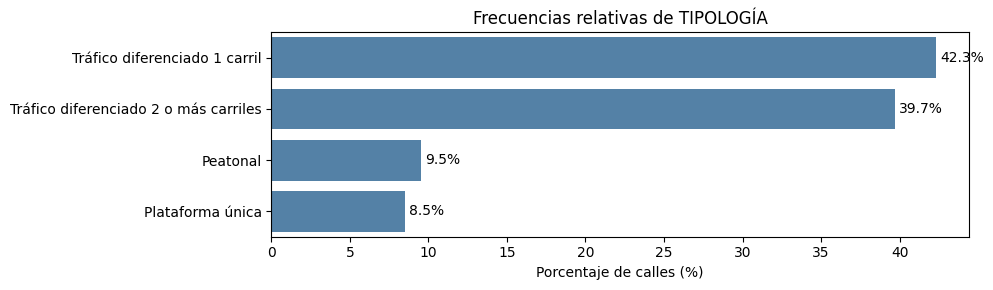

In [15]:
plot_category_frequencies(df_alg_streets_cleaned, 'TIPOLOGÍA')

La columna *TIPOLOGÍA* contiene 4 valores diferentes, principalmente de tráfico diferenciado (1 o 2 más carriles, más del 80% de las calles), 48 peatonales y 43 de plataforma única.

La mayoría de calles tienen tráfico diferenciado (82%).

,count,percentage
PROPUESTA,,
Mejora en Vía existente: Tráfico diferenciado 2 o más carriles,179,35.4
Cambio de Tipología: Plataforma,148,29.2
Mejora en Vía existente: Tráfico diferenciado 1 carril,90,17.8
Mejora en Vía existente: Plataforma única,42,8.3
Mejora en Vía existente: Peatonal,38,7.5
Cambio de Tipología: Plataforma uso restringido,8,1.6
"Sin propuesta, vía en obras totalmente",1,0.2


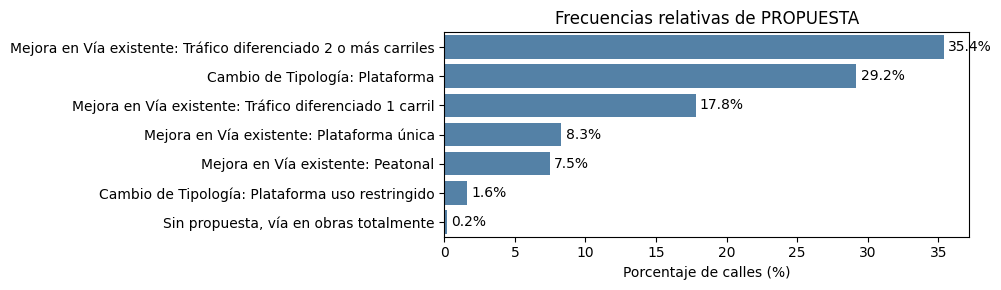

In [16]:
plot_category_frequencies(df_alg_streets_cleaned, 'PROPUESTA')

Mientras que la columna *PROPUESTA* tiene varios valores diferentes, con las propuestas de mejora (se repite la tipología, después de dos puntos). Ejemplo: "Mejora en Vía existente: Tráfico diferenciado 2 o más carriles", o también hay "Cambio de Tipología: Plataforma (o Plataforma uso restringido), así como "Sin propuesta, vía en obras totalmente".

Hay dos categorías que destacan:
* Mejora en vía existente (con tráfico diferenciado 2 o más carriles), con un 35,4%.
* Cambio de tipología (plataforma), con un 29,2%.

Esta columna está muy relacionada con la de tipología, pero si nos centramos únicamente en la propuesta en sí:
* Un 69,0% son mejoras en vías existentes.
* Un 30,8% son cambios de tipología de calle.
* Un 0,2% no tiene propuesta.

Como nota, no hay ninguna calle que no requiera alguna mejora.

,count,percentage
Centro,79,15.6
El Rinconcillo,32,6.3
La Caridad,24,4.7
La Bajadilla,23,4.5
San García,20,4.0
San Bernabé,18,3.6
Adalides,18,3.6
San Isidro,18,3.6
Los Pinos,17,3.4
El Rosario,17,3.4


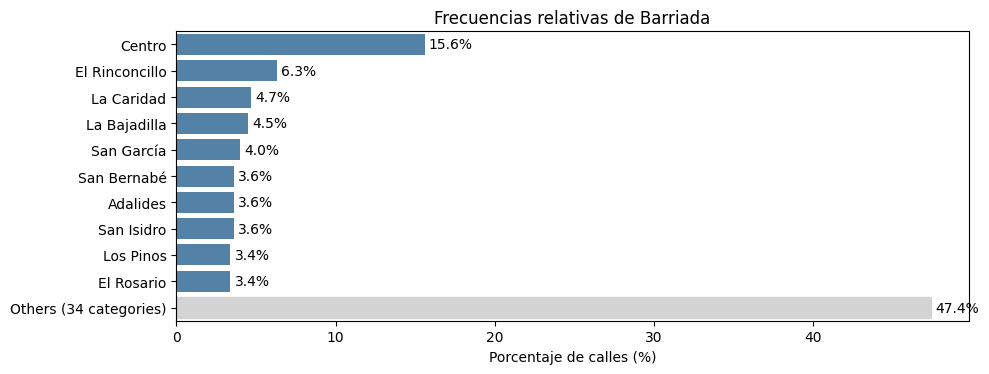

In [17]:
plot_category_frequencies(df_alg_streets_cleaned, 'Barriada')

Hay un total de 44 barriadas, la más frecuente es la del Centro con un 15,6%, seguida de El Rinconcillo (6,3%) o la Caridad (4,7%) o La Bajadilla (4,5%), los 34 barrios con menos frecuencia cuentan con un 47,4% de los datos.

Se puede concluir que no está demasiado bien balanceado el número de calles por barrio, quizás el barrio del centro es más grande, o las calles son más pequeñas.

### PRESUPUESTO
Vamos a analizar la columna PRESUPUESTO:

count    5.060000e+02
mean     1.463188e+05
std      1.844617e+05
min      5.300000e+03
25%      4.022500e+04
50%      8.090000e+04
75%      1.691500e+05
max      1.323800e+06
Name: PRESUPUESTO, dtype: float64

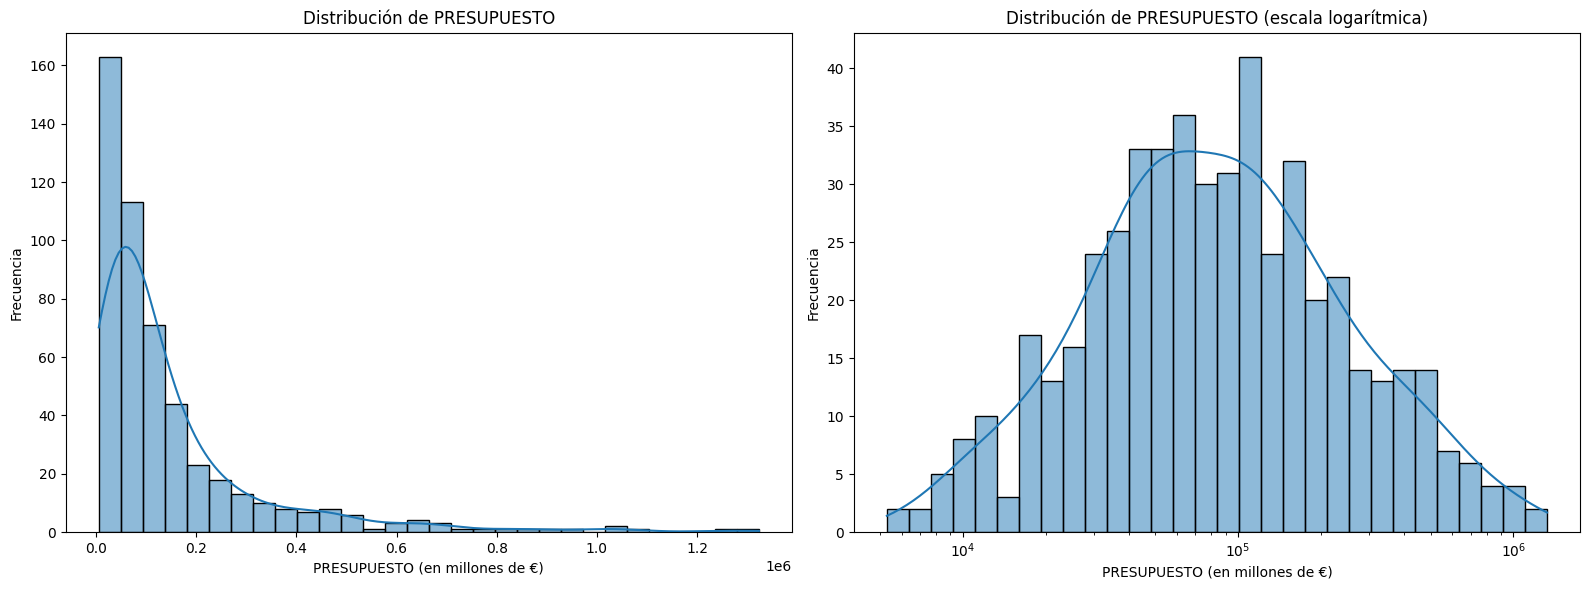

In [18]:
# Analyze column continuous 'PRESUPUESTO'
display(df_alg_streets_cleaned['PRESUPUESTO'].describe())

# Visualize the distribution of 'PRESUPUESTO' on the raw scale and on a log scale
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(df_alg_streets_cleaned['PRESUPUESTO'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribución de PRESUPUESTO')
sns.histplot(df_alg_streets_cleaned['PRESUPUESTO'], bins=30, kde=True, log_scale=True, ax=axes[1])
axes[1].set_title('Distribución de PRESUPUESTO (escala logarítmica)')
for ax in axes:
    ax.set_xlabel('PRESUPUESTO (en millones de €)')
    ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

La mayoría de calles tiene un presupuesto de reparación asignado menor a 200.000 €, con una mediana de 80.900 €.
La distribución es asimétrica a la derecha (la media es mucho más elevada que la mediana, 146.318,77€).

Esto implica que algunas pocas calles concentran la mayoría del presupuesto.

In [19]:
# Show streets sort by 'PRESUPUESTO' descending (top 10)
df_alg_streets_cleaned[['NOMBRE', 'PRESUPUESTO']].sort_values(by='PRESUPUESTO', ascending=False).head(10)

,NOMBRE,PRESUPUESTO
REFERENCIA,,
0005B,Avenida Gesto por la Paz,1323800
0045,Avenida América,1237300
0075,Calle Andalucía,1082300
0082,Calle Paco de Lucía,1027500
0149,Calle 28 De Febrero,1022900
0002,Avenida Virgen del Carmen,967900
0070,Avenida Agua Marina,895000
0029,Avenida De La Bahía,861100
0278,Avenida del Puerto,821300


### Variables PUNT

Se analizan ahora las columnas *PUNT_\**.

En primer lugar todas las columnas tienen el formato PUNT_XXXX_YY.

Analizando la nomenclatura, las primeras 4 letras después de PUNT (XXXX), identifican el criterio o característica (según se ha indicado en la memoria):
* PEND: pendiente
* ANCH: anchura
* PAVI: pavimento
* CRUC: cruces
* SEÑA: señalización
* ILUM: iluminación
* MOBI: mobiliario

Mientras que las últimas letras que forman el sufijo (YY), indican el tipo de diversidad funcional:
* FU: funcional.
* SE: sensorial.
* CG: cognitivo.
* GB: se intuye que indica global. Parece que podría ser la media de los 3 valores anteriores.

Se infiere que las puntuaciones son sobre un criterio, y en base a un tipo de diversidad funcional.

Para comprobar la hipótesis sobre que *GB* es la media, calculamos para cada criterio la diferencia entre *GB* y la media de *FU*, *SE* y *CG*.

In [20]:
# Check that GB is the mean of FU, SE and CG for every criterion
criteria_codes = ['PEND', 'ANCH', 'PAVI', 'CRUC', 'SEÑA', 'ILUM', 'MOBI']
max_difference = pd.Series({
    crit: (df_alg_streets_cleaned[[f'PUNT_{crit}_FU', f'PUNT_{crit}_SE', f'PUNT_{crit}_CG']].mean(axis=1)
           - df_alg_streets_cleaned[f'PUNT_{crit}_GB']).abs().max()
    for crit in criteria_codes
}, name='max abs difference')
display(max_difference)
assert (max_difference < 1e-9).all() # Check that the maximum absolute difference is really low

PEND    3.552714e-15
ANCH    3.552714e-15
PAVI    0.000000e+00
CRUC    3.552714e-15
SEÑA    3.330669e-15
ILUM    2.664535e-15
MOBI    3.552714e-15
Name: max abs difference, dtype: float64

Como se puede comprobar, queda demostrada la intución, por lo que _GB significa la media global.

Identificamos cuántos valores diferentes pueden tener las columnas:

In [21]:
# Distinct values, min and max of every PUNT_* column (the values are only listed for columns with few of them)
punt_columns = [col for col in df_alg_streets_cleaned.columns if col.startswith('PUNT_')]
rows = []
for col in punt_columns:
    unique_values = sorted(df_alg_streets_cleaned[col].unique())
    rows.append({
        'column': col,
        'n_unique': len(unique_values),
        'min': min(unique_values),
        'max': max(unique_values),
        'mean': round(df_alg_streets_cleaned[col].mean(), 2),
        'values': [round(v, 2) for v in unique_values] if len(unique_values) <= 6 else '(many values)',
    })
display(pd.DataFrame(rows).set_index('column'))

,n_unique,min,max,mean,values
column,,,,,
PUNT_PEND_FU,3,0.000000,5.000000,2.91,"[0, 2, 5]"
PUNT_PEND_SE,3,1.000000,4.000000,2.68,"[1, 2, 4]"
PUNT_PEND_CG,3,2.000000,4.000000,3.24,"[2, 3, 4]"
PUNT_PEND_GB,3,1.000000,4.333333,2.94,"[1.0, 2.33, 4.33]"
PUNT_ANCH_FU,3,0.000000,5.000000,2.20,"[0, 3, 5]"
PUNT_ANCH_SE,4,0.000000,4.000000,2.39,"[0, 1, 3, 4]"
PUNT_ANCH_CG,4,0.000000,4.000000,2.04,"[0, 1, 2, 4]"
PUNT_ANCH_GB,4,0.000000,4.333333,2.21,"[0.0, 0.67, 2.67, 4.33]"
PUNT_PAVI_FU,3,1.000000,5.000000,2.17,"[1, 2, 5]"


Todas las columnas tienen valores entre 0 y 5.

A continuación se muestra la distribución de cada uno de los criterios y tipo de diversidad, el porcentaje de puntuaciones 0, 1, 2, 3, 4 y 5. 

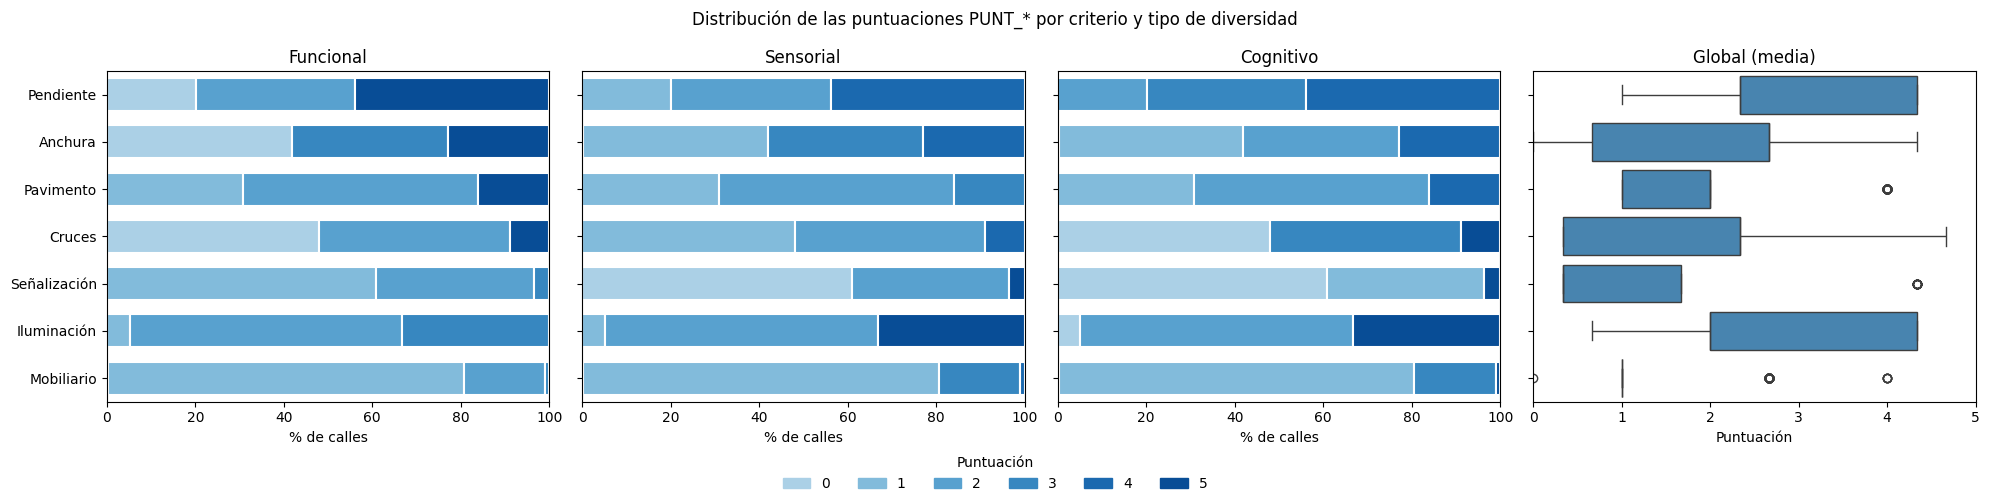

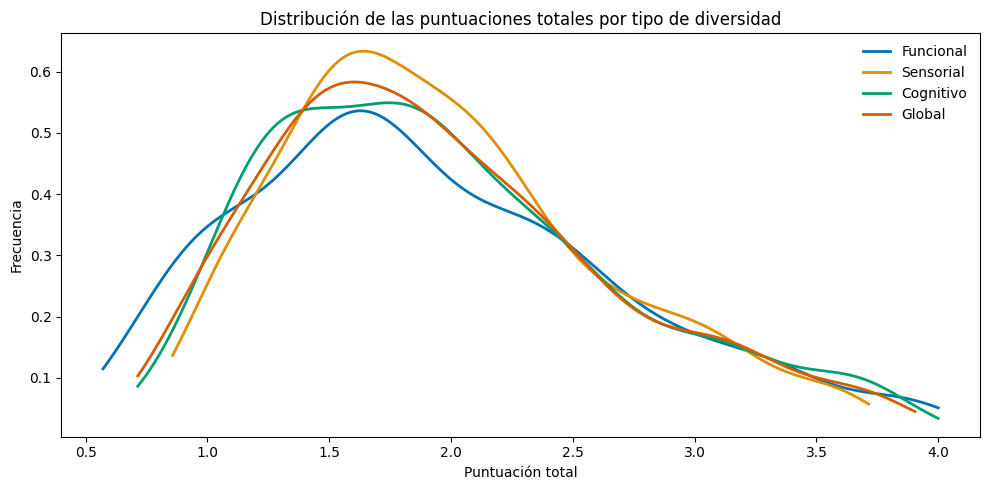

,Funcional,Sensorial,Cognitivo,Global
Pendiente,2.91,2.68,3.24,2.94
Anchura,2.20,2.39,2.04,2.21
Pavimento,2.17,1.85,2.01,2.01
Cruces,1.31,1.70,1.74,1.58
Señalización,1.43,0.89,0.53,0.95
Iluminación,2.28,2.94,2.89,2.71
Mobiliario,1.20,1.40,1.41,1.33
Total,1.93,1.98,1.98,1.96


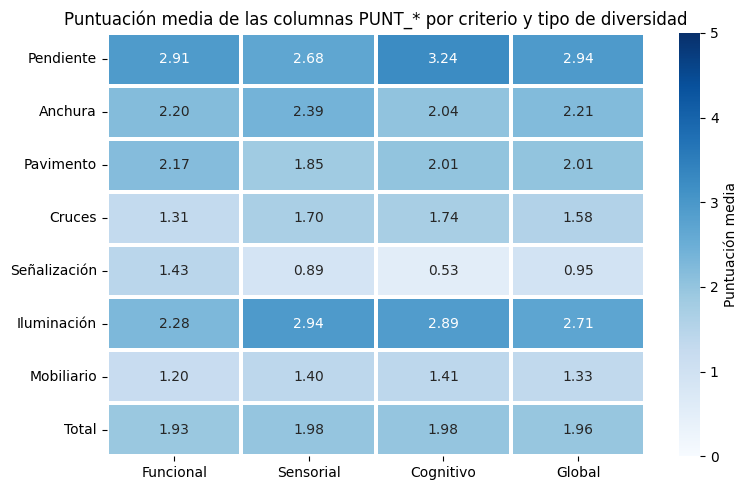

In [22]:
# Scores PUNT_<criterion>_<diversity_type>: diversity types are FU (functional), SE (sensory), CG (cognitive) and GB (global = mean of the three)
criteria = {'PEND': 'Pendiente', 'ANCH': 'Anchura', 'PAVI': 'Pavimento', 'CRUC': 'Cruces', 'SEÑA': 'Señalización', 'ILUM': 'Iluminación', 'MOBI': 'Mobiliario'}
diversity_type = {'FU': 'Funcional', 'SE': 'Sensorial', 'CG': 'Cognitivo'}

# Definition of levels (unique values of the PUNT_* scores for FU, SE and CG) and colours
levels = sorted(pd.unique(df_alg_streets_cleaned[[f'PUNT_{c}_{s}' for c in criteria for s in diversity_type]].values.ravel()))
colors = dict(zip(levels, sns.color_palette('Blues', len(levels) + 2)[2:]))

# Distribution stack diagrams for every criteria
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for ax, (sub, sub_name) in zip(axes, diversity_type.items()):
    scores = df_alg_streets_cleaned[[f'PUNT_{c}_{sub}' for c in criteria]].set_axis(criteria.values(), axis=1)
    share = scores.apply(lambda col: col.value_counts(normalize=True)).T.reindex(columns=levels).fillna(0) * 100
    share.plot(kind='barh', stacked=True, ax=ax, color=[colors[lvl] for lvl in levels], edgecolor='white', linewidth=1.5, width=0.7, legend=False)
    ax.set(title=sub_name, xlabel='% de calles', xlim=(0, 100))
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=colors[lvl]) for lvl in levels], labels=[str(lvl) for lvl in levels],
           title='Puntuación', loc='lower center', ncol=len(levels), frameon=False)

# Box diagram with the global scores (GB) per criterio
gb = df_alg_streets_cleaned[[f'PUNT_{c}_GB' for c in criteria]].set_axis(criteria.values(), axis=1)
sns.boxplot(data=gb, orient='h', color=colors[levels[len(levels) // 2]], linewidth=1, ax=axes[3])
axes[3].set(title='Global (media)', xlabel='Puntuación', xlim=(0, 5))
fig.suptitle('Distribución de las puntuaciones PUNT_* por criterio y tipo de diversidad')
plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

# Distribution of the total scores (per diversity type and global) which are means of the criteria
total_columns = {'PUNT_TOTAL_FU': 'Funcional', 'PUNT_TOTAL_SE': 'Sensorial', 'PUNT_TOTAL_CG': 'Cognitivo', 'PUNT_TOTAL': 'Global'}
plt.figure(figsize=(10, 5))
for (col, name), color in zip(total_columns.items(), sns.color_palette('colorblind', len(total_columns))):
    sns.kdeplot(df_alg_streets_cleaned[col], label=name, color=color, linewidth=2, cut=0)
plt.title('Distribución de las puntuaciones totales por tipo de diversidad')
plt.xlabel('Puntuación total')
plt.ylabel('Frecuencia')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# Mean score per criteria (rows) and diversity type (columns), including the total scores
criteria_codes = ['PEND', 'ANCH', 'PAVI', 'CRUC', 'SEÑA', 'ILUM', 'MOBI']
criteria_names = ['Pendiente', 'Anchura', 'Pavimento', 'Cruces', 'Señalización', 'Iluminación', 'Mobiliario', 'Total']
punt_panels = {
    'Funcional': [f'PUNT_{c}_FU' for c in criteria_codes] + ['PUNT_TOTAL_FU'],
    'Sensorial': [f'PUNT_{c}_SE' for c in criteria_codes] + ['PUNT_TOTAL_SE'],
    'Cognitivo': [f'PUNT_{c}_CG' for c in criteria_codes] + ['PUNT_TOTAL_CG'],
    'Global': [f'PUNT_{c}_GB' for c in criteria_codes] + ['PUNT_TOTAL'],
}
mean_score = pd.DataFrame({panel: df_alg_streets_cleaned[columns].mean().values for panel, columns in punt_panels.items()}, index=criteria_names)
display(mean_score.round(2))

# Heatmap of the mean scores per criteria and diversity type
plt.figure(figsize=(8, 5))
sns.heatmap(mean_score, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=5, linewidths=1.5, linecolor='white',
            cbar_kws={'label': 'Puntuación media'})
plt.title('Puntuación media de las columnas PUNT_* por criterio y tipo de diversidad')
plt.tight_layout()
plt.show()

Las distribuciones de las nos indican que los criterios con mejor valoración son:
* Pendiente.
* Iluminación.

Mientras que los criterios con peor puntuación son todos los demás: pavimento, cruces, señalización, anchura y mobiliario (prácticamente todo unos).

En cada uno de los criterios, las valoraciones parecen tener únicamente 3 valores distintos, o como mucho 4. Se detecta algún outlier positivo en pavimento, señalización o mobiliario.

En cuanto a diferencia por tipo de diversidad funcional, la que obtiene peores puntuaciones es la de funcional (entendiéndose como personas con problemas de movilidad), mientras que las puntuaciones para sensorial y cognitivo son similares.

### Variables PIC
Se analizan ahora las columnas *PIC_\**, que contienen una clase (A, B o C) en lugar de una puntuación. Siguen una nomenclatura parecida a la de *PUNT_\**, aunque con alguna abreviatura distinta (por ejemplo *CRUCE* y *SEÑAL*):
* *PIC_XXXX_YY*: criterio (XXXX) y tipo de diversidad (YY: FU, SE o CG).
* *PIC_XXXX*: criterio, sin tipo de diversidad.
* *PIC_TOTAL*, *PIC_FUNC*, *PIC_SENS* y *PIC_COGN*: totales (global y por tipo de diversidad).

Primero se muestra, para cada columna, cuántos valores distintos tiene y cuántas calles hay en cada clase:

In [23]:
# Classes (C < B < A) of every PIC_* column: number of distinct values and number of streets in each class
pic_columns = [col for col in df_alg_streets_cleaned.columns if col.startswith('PIC_')]
pic_summary = pd.DataFrame({col: df_alg_streets_cleaned[col].value_counts() for col in pic_columns}).T
pic_summary.insert(0, 'n_unique', (pic_summary > 0).sum(axis=1))
display(pic_summary)

,n_unique,C,B,A
PIC_TOTAL,3,194,284,28
PIC_FUNC,3,211,266,29
PIC_SENS,3,181,308,17
PIC_COGN,3,187,290,29
PIC_PEND,3,102,182,222
PIC_ANCH,3,212,178,116
PIC_PAVI,3,156,269,81
PIC_CRUCE,3,243,218,45
PIC_SEÑAL,3,308,180,18
PIC_ILUM,3,26,312,168


A continuación se muestra el porcentaje de calles de cada clase, por criterio y tipo de diversidad.

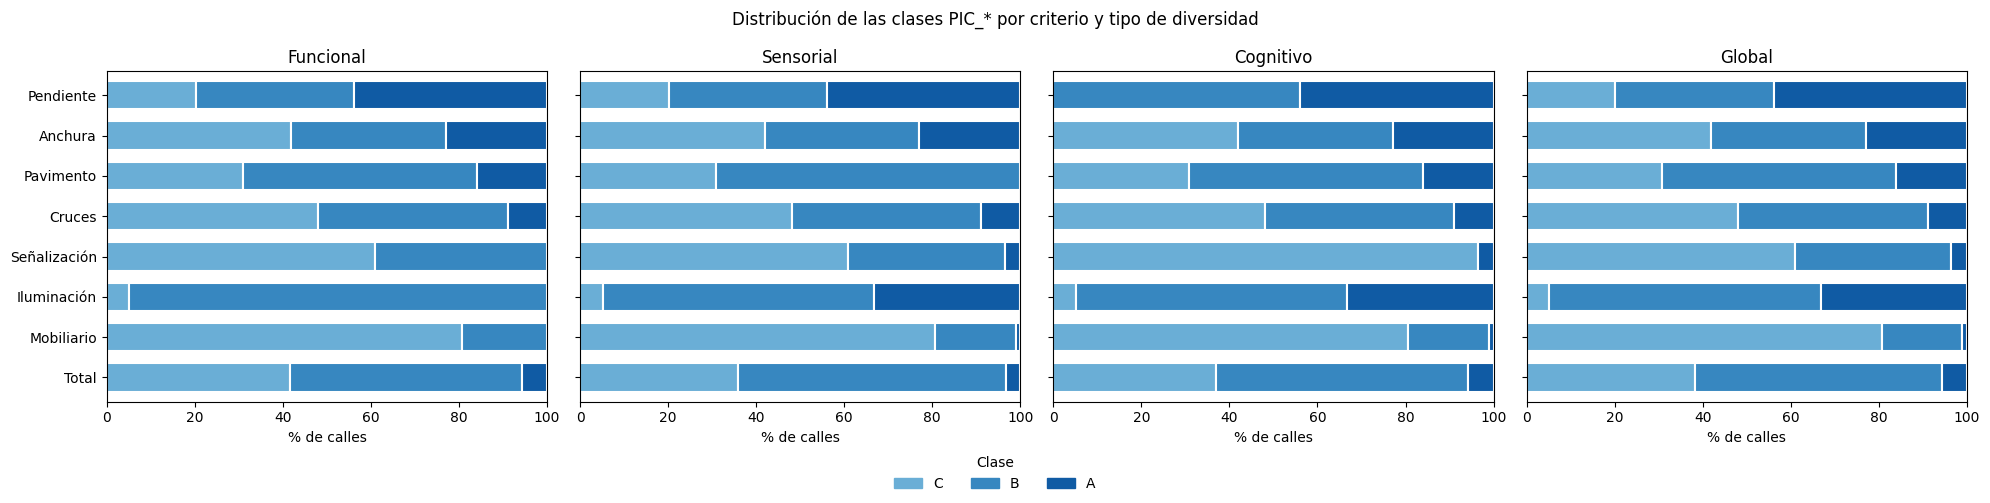

In [24]:
# PIC_<criterion>_<diversity_type> columns and the totals: FUNC, SENS and COGN are the totals per diversity type, TOTAL is the global one
criteria_codes = ['PEND', 'ANCH', 'PAVI', 'CRUC', 'SEÑA', 'ILUM', 'MOBI']
criteria_names = ['Pendiente', 'Anchura', 'Pavimento', 'Cruces', 'Señalización', 'Iluminación', 'Mobiliario', 'Total']
pic_panels = {
    'Funcional': [f'PIC_{c}_FU' for c in criteria_codes] + ['PIC_FUNC'],
    'Sensorial': [f'PIC_{c}_SE' for c in criteria_codes] + ['PIC_SENS'],
    'Cognitivo': [f'PIC_{c}_CG' for c in criteria_codes] + ['PIC_COGN'],
    'Global': ['PIC_PEND', 'PIC_ANCH', 'PIC_PAVI', 'PIC_CRUCE', 'PIC_SEÑAL', 'PIC_ILUM', 'PIC_MOBI', 'PIC_TOTAL'],
}

# Classes in order (C < B < A) and colours, light for the worst class and dark for the best
classes = list(df_alg_streets_cleaned['PIC_TOTAL'].cat.categories)
class_colors = dict(zip(classes, sns.color_palette('Blues', len(classes) + 2)[2:]))

# Distribution stack diagrams for every criterion
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for ax, (panel_name, columns) in zip(axes, pic_panels.items()):
    share = pd.DataFrame({name: df_alg_streets_cleaned[col].value_counts(normalize=True)
                          for name, col in zip(criteria_names, columns)}).T * 100
    share.plot(kind='barh', stacked=True, ax=ax, color=[class_colors[c] for c in classes], edgecolor='white', linewidth=1.5, width=0.7, legend=False)
    ax.set(title=panel_name, xlabel='% de calles', xlim=(0, 100))
axes[0].invert_yaxis()
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=class_colors[c]) for c in classes], labels=classes,
           title='Clase', loc='lower center', ncol=len(classes), frameon=False)
fig.suptitle('Distribución de las clases PIC_* por criterio y tipo de diversidad')
plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

Para tener más información, se realiza con las clases *PIC_\** el mismo análisis que con las puntuaciones *PUNT_\**. Para ello se transforman las clases a valores numéricos (C = 1, B = 2 y A = 3) en una copia del conjunto de datos, de modo que las columnas originales se mantienen como categorías.

Con esta codificación se calcula la clase media por criterio y tipo de diversidad. Solo se utiliza para poder describir mejro los datos.

,Funcional,Sensorial,Cognitivo,Global
Pendiente,2.24,2.24,2.44,2.24
Anchura,1.81,1.81,1.81,1.81
Pavimento,1.85,1.69,1.85,1.85
Cruces,1.61,1.61,1.61,1.61
Señalización,1.39,1.43,1.07,1.43
Iluminación,1.95,2.28,2.28,2.28
Mobiliario,1.19,1.20,1.20,1.20
Total,1.64,1.68,1.69,1.67


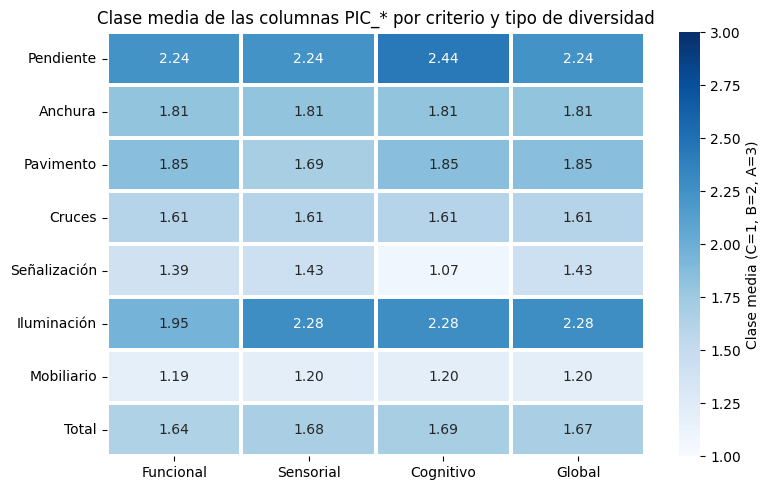

In [25]:
# Numeric copy of the PIC_* classes (C=1, B=2, A=3); the categorical columns are kept as they are
df_pic_numeric = df_alg_streets_cleaned[pic_columns].apply(lambda col: col.cat.codes + 1)
assert (df_pic_numeric > 0).all().all()

# Mean class per criterion (rows) and diversity type (columns), using the panels defined above
mean_class = pd.DataFrame({panel: [df_pic_numeric[col].mean() for col in columns] for panel, columns in pic_panels.items()}, index=criteria_names)
display(mean_class.round(2))

plt.figure(figsize=(8, 5))
sns.heatmap(mean_class, annot=True, fmt='.2f', cmap='Blues', vmin=1, vmax=3, linewidths=1.5, linecolor='white',
            cbar_kws={'label': 'Clase media (C=1, B=2, A=3)'})
plt.title('Clase media de las columnas PIC_* por criterio y tipo de diversidad')
plt.tight_layout()
plt.show()

Comprobamos de nuevo que las puntuaciones más elevadas se dan en pendiente e iluminación, seguidas de anchura.
La peor puntuación se la llev el mobiliario, además de la señalización. En este caso, la puntuación total parece algo peor en el tipo de diversidad funcional.

### FASE
Se analiza ahora la columna *FASE*, que toma los valores 1, 2 y 3 (es una variable categórica), que tiene 3 valores como las variables PIC_*.
Se muestra el número y el porcentaje de calles en cada fase, y se cruza con la clase total (*PIC_TOTAL*) para ver cómo se relacionan.

,count,percentage
FASE,,
1,194,38.3
2,284,56.1
3,28,5.5


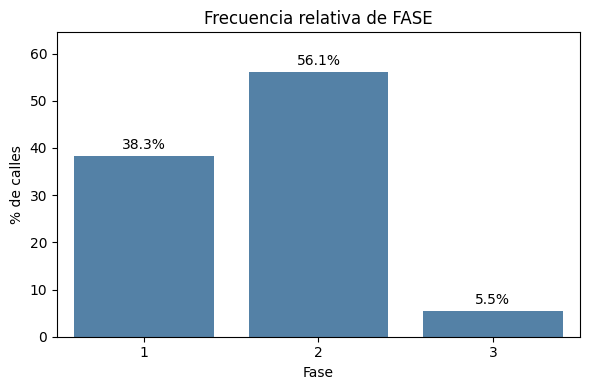

FASE,1,2,3
PIC_TOTAL,,,
C,194,0,0
B,0,284,0
A,0,0,28


In [26]:
# Number and percentage of streets in each phase, in order (1 < 2 < 3)
phase_counts = df_alg_streets_cleaned['FASE'].value_counts().sort_index()
phase_summary = pd.DataFrame({'count': phase_counts, 'percentage': (phase_counts / phase_counts.sum() * 100).round(1)})
display(phase_summary)

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=phase_summary.index.astype(str), y=phase_summary['percentage'], color='steelblue')
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
ax.margins(y=0.15)
ax.set(title='Frecuencia relativa de FASE', xlabel='Fase', ylabel='% de calles')
plt.tight_layout()
plt.show()

# Relation between the phase and the total class
display(pd.crosstab(df_alg_streets_cleaned['PIC_TOTAL'], df_alg_streets_cleaned['FASE']))

Por lo que podemos concluir que la variable Fase se relaciona de manera inversa a la variable PIC_TOTAL, por lo que la fase del proyecto parece relacionada con las puntuaciones C. Parece tratarse de las calles con prioridad de actuación o reparación.

## Análisis de la relación entre PUNT_* y PIC_*

Para ver cómo se relacionan las puntuaciones y las clases, analizamos los totales: *PUNT_TOTAL* y *PIC_TOTAL*.
A la izquierda se representa cada valor de PUNT_TOTAL como un punto.
A la derecha se muestra la distribución de la puntuación total, con colores diferentes por clase.

Para poder comprobar la distribución de la variable PUNT_TOTAL (numérica) frente a PIC_TOTAL (categórica), vamos a utilizar un diagrama de dispersión (strpplot), y un histograma (histplot).

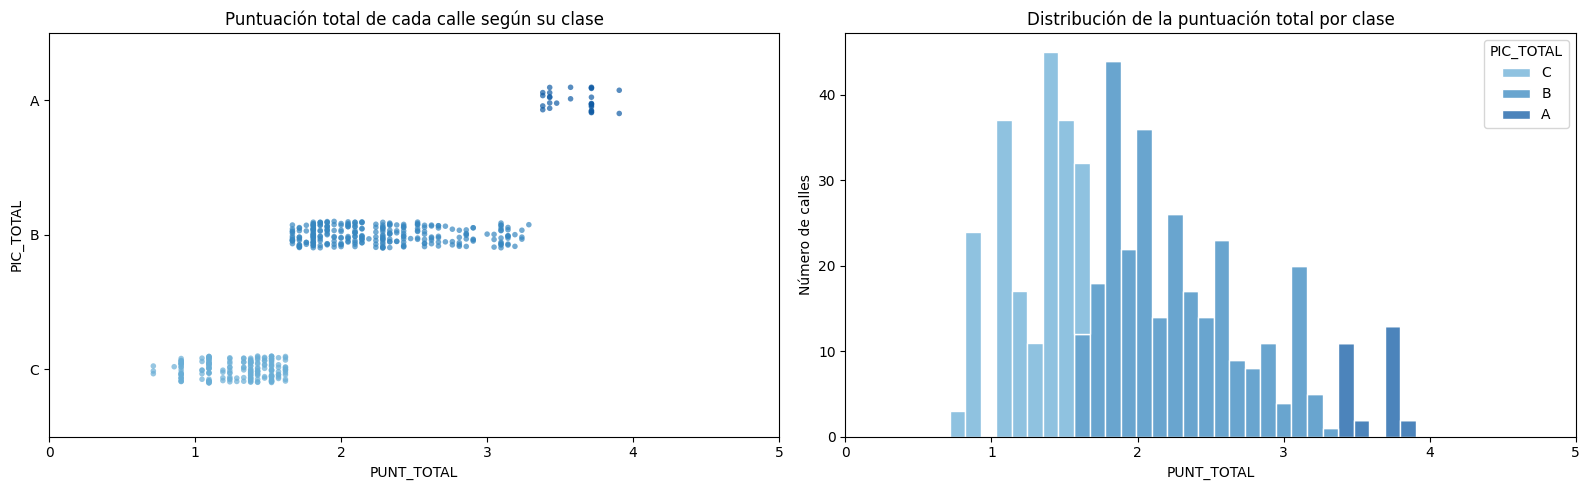

In [27]:
# Relation between the total score (PUNT_TOTAL) and the total class (PIC_TOTAL)
classes = list(df_alg_streets_cleaned['PIC_TOTAL'].cat.categories)
class_colors = dict(zip(classes, sns.color_palette('Blues', len(classes) + 2)[2:]))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: every punt_total as a point, grouped by pic_total
sns.stripplot(data=df_alg_streets_cleaned, x='PUNT_TOTAL', y='PIC_TOTAL', hue='PIC_TOTAL', order=classes[::-1], hue_order=classes,
              palette=class_colors, size=4, alpha=0.7, legend=False, ax=axes[0])
axes[0].set(title='Puntuación total de cada calle según su clase', xlabel='PUNT_TOTAL', ylabel='PIC_TOTAL')

# Right: distribution of the total score, coloured by class
sns.histplot(data=df_alg_streets_cleaned, x='PUNT_TOTAL', hue='PIC_TOTAL', hue_order=classes, palette=class_colors,
             multiple='stack', bins=30, edgecolor='white', ax=axes[1])
axes[1].set(title='Distribución de la puntuación total por clase', xlabel='PUNT_TOTAL', ylabel='Número de calles')

for ax in axes:
    ax.set_xlim(0, 5)
    ax.set_xticks([0, 1, 2, 3, 4, 5], ['0', '1', '2', '3', '4', '5'])
plt.tight_layout()
plt.show()

Podemos comprobar que la las variables tienen una correlación muy alta, todos los valores de C son menores a 2, mientras que todos los valores de A son mayores a 3, y los valores de B están en el medio.

Vamos a comprobar a continuación cuál es el mayor valor de C, el menor y el mayor de B, y el menor de A.

In [28]:
# Lowest and highest PUNT_TOTAL of each class (C < B < A)
limits = df_alg_streets_cleaned.groupby('PIC_TOTAL', observed=True)['PUNT_TOTAL'].agg(['min', 'max'])
display(limits)

print(f"Highest value of C: {limits.loc['C', 'max']:.4f}")
print(f"Lowest value of B:  {limits.loc['B', 'min']:.4f}")
print(f"Highest value of B: {limits.loc['B', 'max']:.4f}")
print(f"Lowest value of A:  {limits.loc['A', 'min']:.4f}")

# The classes do not overlap: each class ends before the next one starts
assert limits.loc['C', 'max'] < limits.loc['B', 'min'] and limits.loc['B', 'max'] < limits.loc['A', 'min']

,min,max
PIC_TOTAL,,
C,0.714286,1.619048
B,1.666667,3.285714
A,3.380952,3.904762


Highest value of C: 1.6190
Lowest value of B:  1.6667
Highest value of B: 3.2857
Lowest value of A:  3.3810


Los valores menores a 1,62 están en la clase C, los valores mayores a 1,66 y menores de 3,29 están en la clase B, mientras que los valores mayores que 3,38 están en A, por lo que parece que la clase PIC_TOTAL se saca a partir de los valores de PUNT_TOTAL.

Los valores están cercanos a 5/3 = 1,67 y 2*5/3 = 3,33... por lo que podemos inferir que tiene pinta de que se dejan las puntuaciones inferiores al tercio del máximo en la clase C, las del 33% más cerca del máximo a la clase A, y 33% entre medias a la clase B.

Para cerciorarnos del todo, comprobamos todas las relaciones entre PUNT_* y PIC_*, mostrando en los diagramas de dispersión dos líneas, la primera el 1/3 de la máxima puntuación (5), la segunda en 2/3 de la máxima puntuación (5)

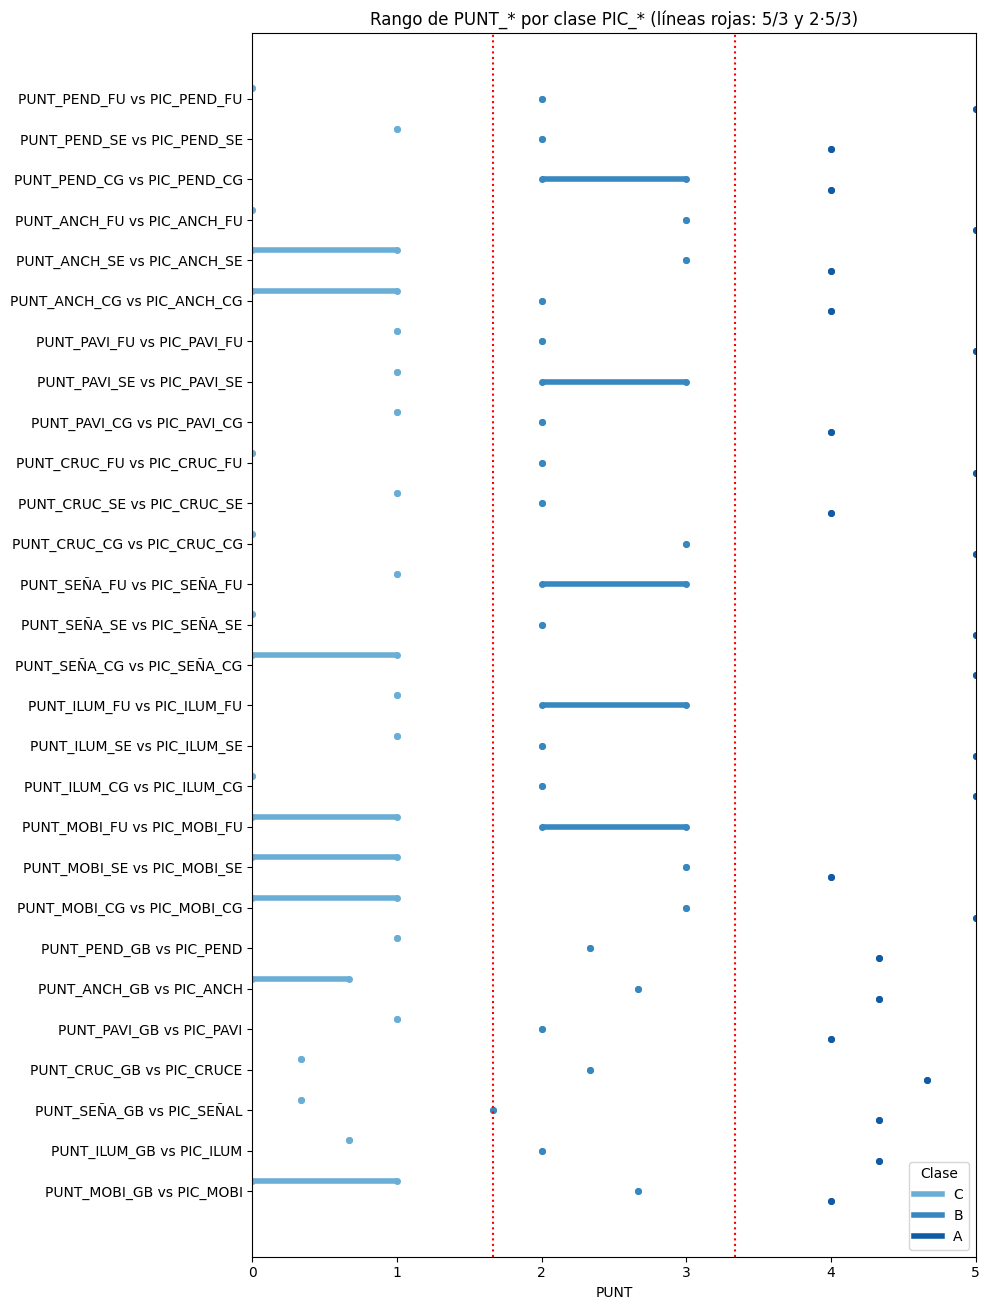

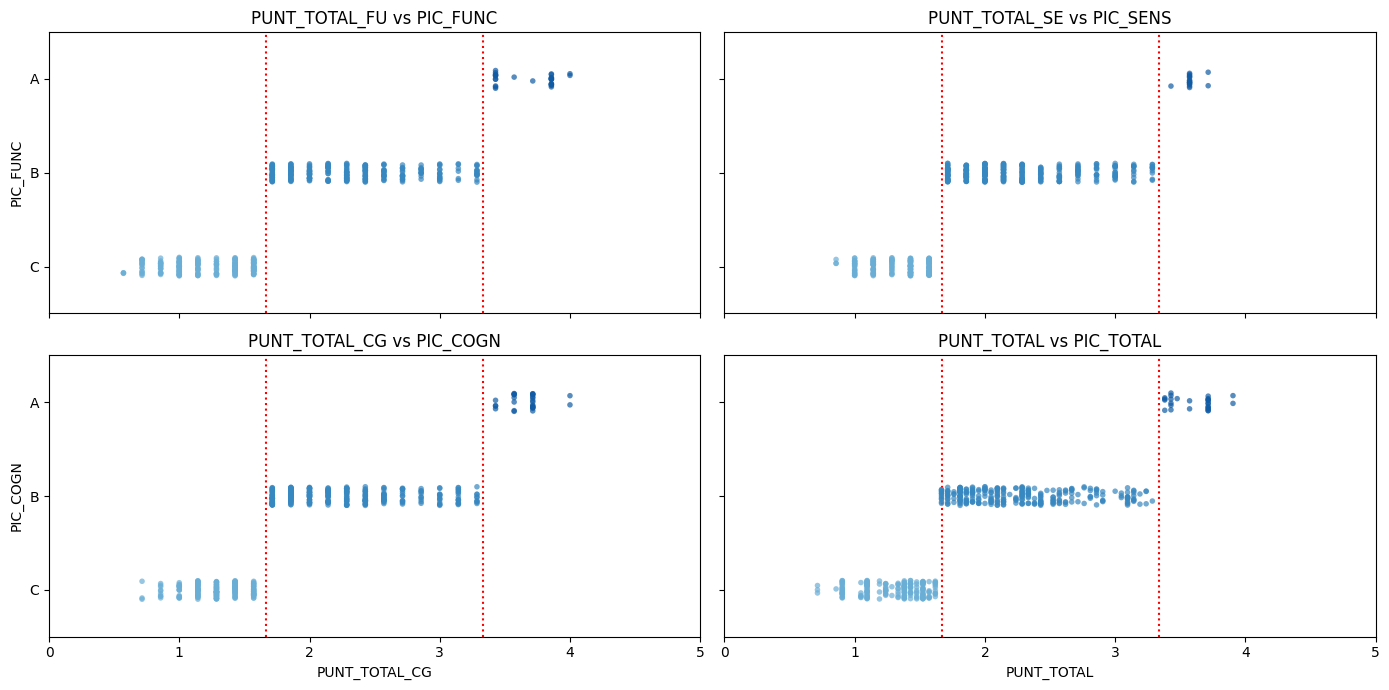

,pair,cls,min,max


In [29]:
# Stripplots of every PUNT_* column against its PIC_* class, with the class thresholds at 5/3 and 2*5/3
pic_of = {  # (criterion, diversity type) -> (PUNT column, PIC column)
    **{(c, s): (f'PUNT_{c}_{s}', f'PIC_{c}_{s}') for c in criteria_codes for s in ['FU', 'SE', 'CG']},
    **{(c, 'GB'): (f'PUNT_{c}_GB', f'PIC_{p}') for c, p in zip(criteria_codes, ['PEND', 'ANCH', 'PAVI', 'CRUCE', 'SEÑAL', 'ILUM', 'MOBI'])},
    ('TOTAL', 'FU'): ('PUNT_TOTAL_FU', 'PIC_FUNC'), ('TOTAL', 'SE'): ('PUNT_TOTAL_SE', 'PIC_SENS'),
    ('TOTAL', 'CG'): ('PUNT_TOTAL_CG', 'PIC_COGN'), ('TOTAL', 'GB'): ('PUNT_TOTAL', 'PIC_TOTAL'),
}

# Criterion pairs -> range plot; total pairs (PUNT_TOTAL*) -> stripplots. Thresholds at 5/3 and 2*5/3
total_pairs = {k: v for k, v in pic_of.items() if k[0] == 'TOTAL'}
criterion_pairs = [v for k, v in pic_of.items() if k[0] != 'TOTAL']
classes = list(df_alg_streets_cleaned['PIC_TOTAL'].cat.categories)  # C < B < A
class_colors = dict(zip(classes, sns.color_palette('Blues', len(classes) + 2)[2:]))
thresholds = (5 / 3, 2 * 5 / 3)

# 1) Range plot (min-max of PUNT inside each class) for the criterion pairs
ranges = pd.DataFrame([
    {'pair': f'{p} vs {c}', 'cls': cl, 'min': g.min(), 'max': g.max()}
    for p, c in criterion_pairs
    for cl, g in df_alg_streets_cleaned.groupby(c, observed=True)[p]
])
pairs = list(dict.fromkeys(ranges['pair']))
offset = {'C': -0.25, 'B': 0, 'A': 0.25}

fig, ax = plt.subplots(figsize=(10, 0.4 * len(pairs) + 2))
for r in ranges.itertuples():
    y = pairs.index(r.pair) + offset[r.cls]
    ax.hlines(y, r.min, r.max, color=class_colors[r.cls], linewidth=4)
    ax.plot([r.min, r.max], [y, y], 'o', color=class_colors[r.cls], markersize=4)  # single-value ranges stay visible
for t in thresholds:
    ax.axvline(t, color='red', linestyle=':', linewidth=1.5)
ax.set(xlim=(0, 5), yticks=range(len(pairs)), yticklabels=pairs, xlabel='PUNT',
       title='Rango de PUNT_* por clase PIC_* (líneas rojas: 5/3 y 2·5/3)')
ax.invert_yaxis()
ax.legend(handles=[plt.Line2D([], [], color=class_colors[c], linewidth=4, label=c) for c in classes], title='Clase', loc='lower right')
plt.tight_layout()
plt.show()

# 2) Stripplots for the totals, which take many distinct values (continuous variables)
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True, sharey=True)
for ax, (punt_col, pic_col) in zip(axes.ravel(), total_pairs.values()):
    sns.stripplot(data=df_alg_streets_cleaned, x=punt_col, y=pic_col, hue=pic_col, order=classes[::-1], hue_order=classes,
                  palette=class_colors, size=4, alpha=0.7, legend=False, ax=ax)
    for t in thresholds:
        ax.axvline(t, color='red', linestyle=':', linewidth=1.5)
    ax.set(xlim=(0, 5), title=f'{punt_col} vs {pic_col}', xlabel=punt_col, ylabel=pic_col)
plt.tight_layout()
plt.show()

# Table showing the PUNT_* vs PIC_* pairs whose PIC_* falls outside the expected thirds
bounds = {'C': (0, thresholds[0]), 'B': thresholds, 'A': (thresholds[1], 5)}
all_ranges = pd.DataFrame([
    {'pair': f'{p} vs {c}', 'cls': cl, 'min': g.min(), 'max': g.max()}
    for p, c in pic_of.values()
    for cl, g in df_alg_streets_cleaned.groupby(c, observed=True)[p]
])
display(all_ranges[all_ranges.apply(lambda r: r['min'] < bounds[r['cls']][0] or r['max'] > bounds[r['cls']][1], axis=1)])

Por lo tanto, se concluye que la hipótesis sigue cumpliéndose para todas las variables.

## Relaciones entre variables

A continuación se va a realizar un análisis de relaciones entre algunas variables:
* Presupuesto frente a puntuaciones/clases
* Tipología frente a clase y propuesta
* Barriada frente a clase.

Comenzamos con PRESUPUESTO y PUNT_TOTAL.

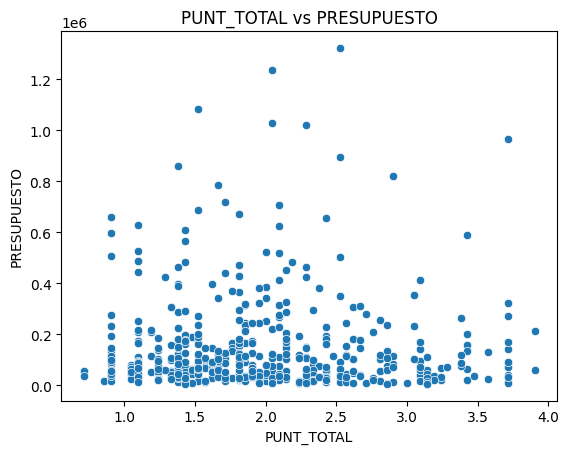

Correlation: -0.059697351239194583


In [30]:
# Scatter plot of PUNT_TOTAL vs PRESUPUESTO
sns.scatterplot(x="PUNT_TOTAL", y="PRESUPUESTO", data=df_alg_streets_cleaned)
plt.title("PUNT_TOTAL vs PRESUPUESTO")
plt.show()

# Correlation between PUNT_TOTAL and PRESUPUESTO
correlation = df_alg_streets_cleaned["PUNT_TOTAL"].corr(df_alg_streets_cleaned["PRESUPUESTO"], method="spearman")
print(f"Correlation: {correlation}")

Vemos que la correlación entre las dos variables es prácticamente nula.

Quizá el presupuesto puede estar asociado al largo de la calle. Tendría sentido, puesto que el conjunto de datos solo distingue entre calles, pero no se indica la longitud de las calles, o incluso el ancho.

## Conclusiones

**Estructura y limpieza**
* El archivo inicial tenía un total de 610 filas, y 73 columnas.
* Se ha realizado una limpieza de las filas que no representaban los datos de las calles (104 eliminadas), así como 2 columnas (solo tenían sentido para las filas eliminadas, que eran de totales o agrupaciones por barrio).
* Se ha modificado el tipo de todas las variables, que estaban identificadas como tipo object. Ahora *PUNT_\**, y *PRESUPUESTO* son numéricas, *PIC_\** y *FASE* son categorías ordenadas, *TIPOLOGÍA*, *PROPUESTA* y *Barriada* son categorías sin orden; mientras que *REFERENCIA* es el índice de la tabla y *NOMBRE* se ha indicado como String.

**Variables categóricas y presupuesto**
* El 82% de las calles tiene tráfico diferenciado. Todas las calles tienen propuesta de actuación, salvo una en obras: un 69% son mejoras de la vía existente y un 30,8% cambios de tipología.
* Hay 44 barriadas muy desiguales: el Centro tiene el 15,6% de las calles, y las 34 menos frecuentes suman el 47,4%.
* El presupuesto es asimétrico a la derecha: mediana de 80.900 € y media de 146.319 €. La mayoría de calles (79%) está por debajo de 200.000 €.

**Puntuaciones PUNT_\***
* Cada puntuación se define por un criterio (pendiente, anchura, pavimento, cruces, señalización, iluminación y mobiliario) y por un tipo de diversidad (funcional, sensorial y cognitiva). *GB* es exactamente la media de las otras tres (con un pequeño error de precisión, totalmente despreciable).
* Todas las puntuaciones están entre 0 y 5 y cada criterio tiene solo 3 o 4 valores distintos.
* Los criterios mejor valorados son la pendiente y la iluminación. Los peores son la señalización, el mobiliario o los cruces.
* La puntuación total apenas cambia entre tipos de diversidad (entre 1,93 y 1,98), aunque hay diferencias por criterio: por ejemplo, la señalización baja de 1,43 (funcional) a 0,53 (cognitiva).

**Clases PIC_\* y fase**
* *PIC_TOTAL* se obtiene a partir de *PUNT_TOTAL*: las clases no se solapan (C llega hasta 1,62, B va de 1,67 a 3,29 y A empieza en 3,38). Como hipótesis, parece que las puntuaciones menores al tercio van a la clase C, las del segundo tercio a clase B y las del primer tercio más alto a clase A.
* Las clases A, B y C reparten las calles de forma muy desigual (debido a que se asignan por puntuación). En el total hay 194 calles en C (38,3%), 284 en B (56,1%) y 28 en A (5,5%). Se repiten los criterios con puntuación más elevada (pendiente o iluminación), y más baja, al igual que las variables PUNT_.
* *FASE* es *PIC_TOTAL* con otra etiqueta (letra en lugar de número): C es la fase 1, B la 2 y A la 3. Parece indicar la prioridad de actuación (y también cómo de problemáticas son las calles para la accesibilidad).

**Implicaciones**
* Una clase y la puntuación de la que sale no son independientes, sino variables derivadas. *GB* tampoco aporta información nueva respecto a *FU*, *SE* y *CG* (es una media), y *FASE* es tal cual *PIC_TOTAL*.

## Guardado del conjunto de datos limpio

Vamos a realizar el guardado del conjunto de datos limpio, en la tabla /data/interim.

In [31]:
# Save dataset in the data/interim/algeciras
INTERIM_ALGECIRAS_DIR.mkdir(parents=True, exist_ok=True)
df_alg_streets_cleaned.to_csv(INTERIM_ALGECIRAS_DIR / "algeciras_streets_cleaned.csv", index=False)

## Dudas y preguntas pendientes

Para el tutor o los autores de los datos:
1. ¿Qué significan las siglas *PIC*? ¿Cómo se definen las clases A, B y C, es cómo se ha intuido en las conclusiones (A > 3,33, C < 1,67)?
2. ¿Cómo se asigna cada puntuación? ¿Hay algún sitio donde se pueda consultar el criterio?
3. ¿Hay algún criterio para elegir entre mejorar la vía y cambiar la tipología?
4. ¿Por qué la puntuación de una calle es igual en todo su recorrido? ¿Cómo se ha realizado la inspección, en un punto específico o aleatorio de la calle, o en varios?
5. Las referencias con letra (por ejemplo, 0003A y 0003B), ¿son la misma calle dividida por barriadas?

## Siguientes pasos

* Analizar las relaciones entre variables: presupuesto frente a puntuaciones/clases, tipología frente a clase y propuesta, y barriada frente a clase.
* Analizar si las calles que están en dos barriadas tienen la misma puntuación o distinta.